```mermaid
flowchart LR
    %% Initial nodes

        A((Sender<br>b3f0))
        B((Relay<br>f02c))
        C((Relay<br>de6c))
        D((Receiver<br>d110))
        E((Relay<br>c998))
        
        %% Full interconnection among initial nodes
        A --> B
        A --> C
        A --> D
        B --> C
        B --> D
        C --> D
        A --> E
        E --> B
        E --> C
        E --> D


```
Fully Connected Topology with single sender and multiple relays

C998 node was added later to the network

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None  # default='warn'

In [13]:
nodes = ['b3f0', 'd110', 'de6c', 'f02c', 'c998']

for node in nodes:
    print(node)
    exec(f"{node} = pd.read_csv('./logs/logs3/{node}.log', sep = '>', header=None, names=['Timestamp', 'Message'])")

b3f0
d110
de6c
f02c
c998


In [14]:
b3f0['Id'] = "B3F0"
d110['Id'] = "D110"
de6c['Id'] = "DE6C"
f02c['Id'] = "F02C"
c998['Id'] = "C998"

Before Addition of C998

In [15]:
df = pd.concat([b3f0, d110, de6c, f02c], ignore_index=True)
df.head()

,Timestamp,Message,Id
0,15:31:31.997,Send packet 1,B3F0
1,15:31:31.998,Sending packet to FFFF,B3F0
2,15:31:32.000,[ 26154][V][LoraMesher.h:250] createPacketAnd...,B3F0
3,15:31:32.009,[ 26166][V][PacketFactory.h:45] createPacket(...,B3F0
4,15:31:32.017,[ 26174][I][PacketFactory.h:74] createPacket(...,B3F0


In [16]:
df.dropna(subset=['Message'], inplace=True)

In [17]:
# convert timestamp to timestamp dtype
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

C:\Users\tripa\AppData\Local\Temp\ipykernel_10752\1537839190.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [18]:
df

,Timestamp,Message,Id
0,2025-07-29 15:31:31.997,Send packet 1,B3F0
1,2025-07-29 15:31:31.998,Sending packet to FFFF,B3F0
2,2025-07-29 15:31:32.000,[ 26154][V][LoraMesher.h:250] createPacketAnd...,B3F0
3,2025-07-29 15:31:32.009,[ 26166][V][PacketFactory.h:45] createPacket(...,B3F0
4,2025-07-29 15:31:32.017,[ 26174][I][PacketFactory.h:74] createPacket(...,B3F0
...,...,...,...
9112,2025-07-29 16:00:02.266,[1739147][V][LoraMesher.cpp:878] processDataP...,F02C
9113,2025-07-29 16:00:02.275,[1739156][I][PacketQueueService.h:80] deleteQ...,F02C
9114,2025-07-29 16:00:02.283,[1739164][I][PacketQueueService.h:83] deleteQ...,F02C
9115,2025-07-29 16:00:02.292,[1739174][V][LoraMesher.cpp:641] processPacke...,F02C


In [19]:
before_c998 = df.copy()
c998['Timestamp'] = pd.to_datetime(c998['Timestamp'])
before_c998 = before_c998[before_c998['Timestamp'] < c998['Timestamp'].min()]
before_c998

C:\Users\tripa\AppData\Local\Temp\ipykernel_10752\2742278553.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  c998['Timestamp'] = pd.to_datetime(c998['Timestamp'])


,Timestamp,Message,Id
0,2025-07-29 15:31:31.997,Send packet 1,B3F0
1,2025-07-29 15:31:31.998,Sending packet to FFFF,B3F0
2,2025-07-29 15:31:32.000,[ 26154][V][LoraMesher.h:250] createPacketAnd...,B3F0
3,2025-07-29 15:31:32.009,[ 26166][V][PacketFactory.h:45] createPacket(...,B3F0
4,2025-07-29 15:31:32.017,[ 26174][I][PacketFactory.h:74] createPacket(...,B3F0
...,...,...,...
7601,2025-07-29 15:39:59.371,[536309][I][RoutingTableService.cpp:206] prin...,F02C
7602,2025-07-29 15:39:59.381,[536319][I][PacketQueueService.h:80] deleteQu...,F02C
7603,2025-07-29 15:39:59.389,[536327][I][PacketQueueService.h:83] deleteQu...,F02C
7604,2025-07-29 15:39:59.398,[536336][V][LoraMesher.cpp:641] processPacket...,F02C


Analyzing DataFrame:
Shape: (2492, 3)
Columns: ['Timestamp', 'Message', 'Id']
First few rows:


,Timestamp,Message,Id
0,2025-07-29 15:31:31.997,Send packet 1,B3F0
1,2025-07-29 15:31:31.998,Sending packet to FFFF,B3F0
2,2025-07-29 15:31:32.000,[ 26154][V][LoraMesher.h:250] createPacketAnd...,B3F0
3,2025-07-29 15:31:32.009,[ 26166][V][PacketFactory.h:45] createPacket(...,B3F0
4,2025-07-29 15:31:32.017,[ 26174][I][PacketFactory.h:74] createPacket(...,B3F0


All Routing Packets Received: 
(40, 3)


,Timestamp,Message,Id
86,2025-07-29 15:33:11.661,[125820][I][RoutingTableService.cpp:77] proce...,B3F0
101,2025-07-29 15:33:11.811,[125970][I][RoutingTableService.cpp:77] proce...,B3F0
117,2025-07-29 15:33:12.864,[127024][I][RoutingTableService.cpp:77] proce...,B3F0
251,2025-07-29 15:35:11.750,[245931][I][RoutingTableService.cpp:77] proce...,B3F0
267,2025-07-29 15:35:12.565,[246746][I][RoutingTableService.cpp:77] proce...,B3F0


All Routing Packets Sent: 
(16, 3)


...

,Timestamp,Message,Id
0,2025-07-29 15:31:31.997,Send packet 1,B3F0
16,2025-07-29 15:31:52.191,Send packet 2,B3F0
32,2025-07-29 15:32:12.404,Send packet 3,B3F0
48,2025-07-29 15:32:32.611,Send packet 4,B3F0
64,2025-07-29 15:32:52.815,Send packet 5,B3F0


Final Messages Sent: 


,Timestamp,Message,Id,Type
0,2025-07-29 15:33:13.785,[127946][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
1,2025-07-29 15:35:13.832,[248012][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
2,2025-07-29 15:37:13.931,[368078][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
3,2025-07-29 15:39:14.007,[488144][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
4,2025-07-29 15:33:10.996,[127953][V][LoraMesher.cpp:598] sendHelloPack...,D110,Routing


Types per Node:


<Figure size 1000x600 with 0 Axes>

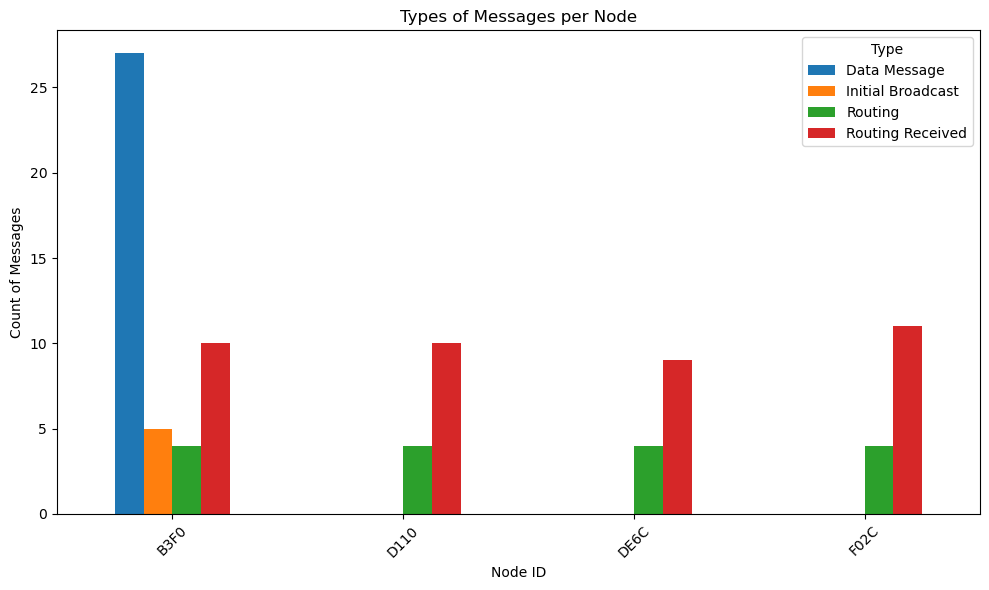

Packet Delivery Ratio (PDR):


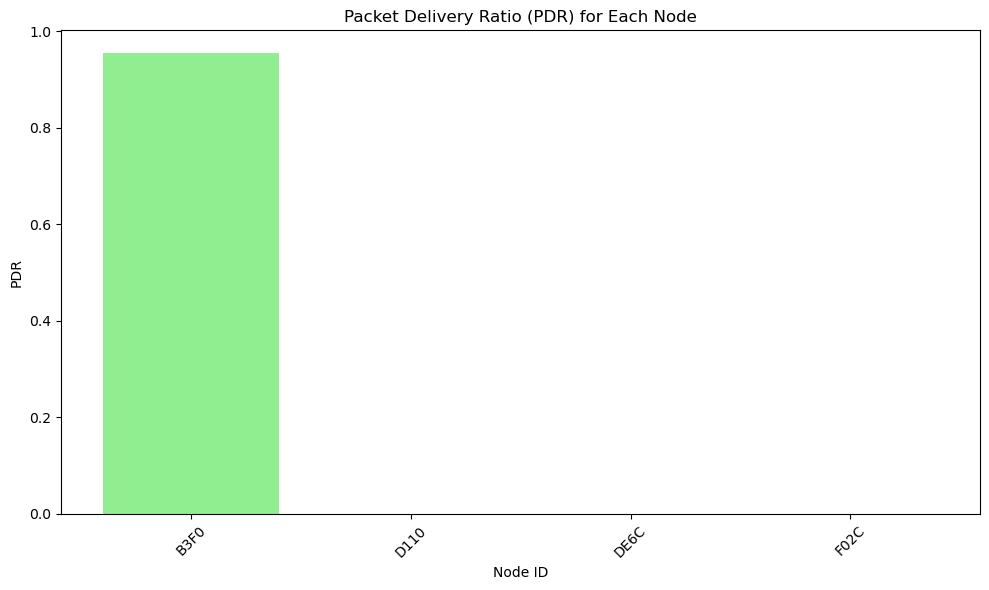

C:\Users\tripa\AppData\Local\Temp\ipykernel_10752\624477972.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([time_diff[id].dt.total_seconds() for id in time_diff.keys()], labels=time_diff.keys())


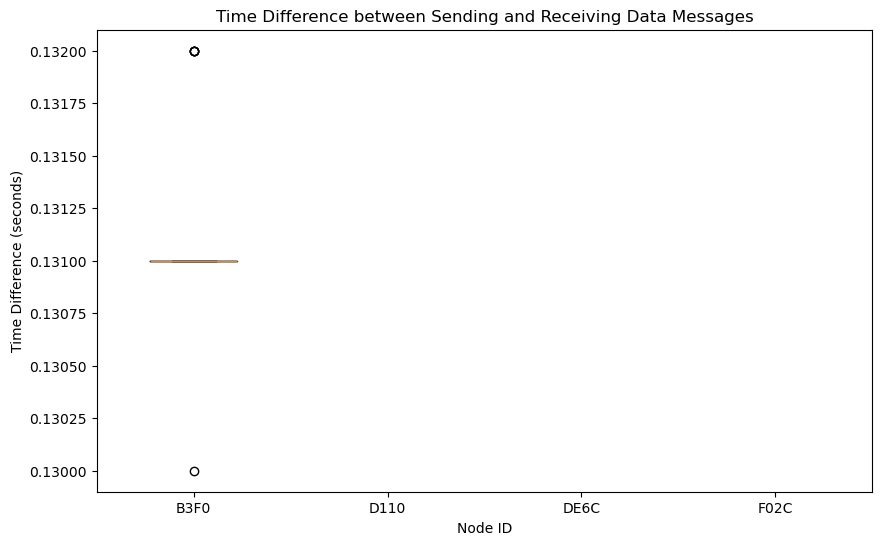

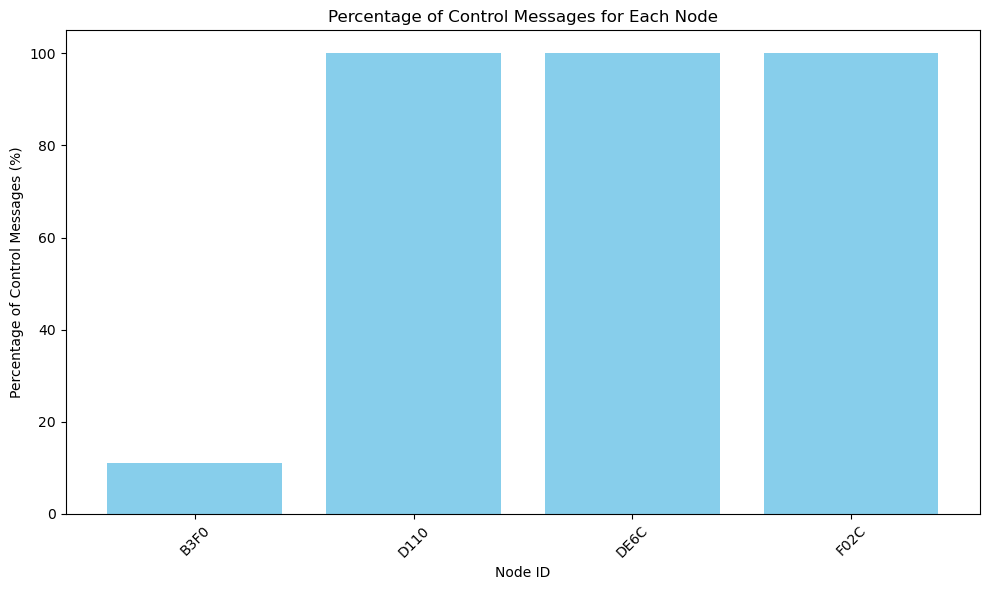

In [ ]:
def analyze(df):
    print("Analyzing DataFrame:")
    print(f"Shape: {df.shape}")

    print(f"Columns: {df.columns.tolist()}")

    print("First few rows:")
    display(df.head())

    print("All Routing Packets Received: ")
    routing_df_rec = df[df['Message'].str.contains('Route packet from')]
    print(routing_df_rec.shape)
    display(routing_df_rec.head())

    print("All Routing Packets Sent: ")
    routing_df_send = df[df['Message'].str.contains('Creating Routing Packet')]
    print(routing_df_send.shape)
    display(routing_df_send.head())

    print("All Forwarding Packets: ")
    forward_df = df[df['Message'].str.contains('Forwarding it')]
    print(forward_df.shape)
    display(forward_df.head())

    print("Initial Broadcast Packets: ")
    initial_broadcast_df = df[df['Message'].str.contains('Sending packet to FFFF')]
    print(initial_broadcast_df.shape)
    display(initial_broadcast_df.head())

    print("Data Messages: ")
    data_msg_df = df[(df['Message'].str.contains('Send packet'))]
    print(data_msg_df.shape)
    display(data_msg_df.head())

    print("Final Messages Sent: ")
    routing_df_send['Type'] = "Routing"
    routing_df_rec['Type'] = "Routing Received"
    forward_df['Type'] = "Forwarding"
    initial_broadcast_df['Type'] = "Initial Broadcast"
    data_msg_df['Type'] = "Data Message"
    df_combined = pd.concat([routing_df_send, routing_df_rec, forward_df, initial_broadcast_df, data_msg_df], ignore_index=True)
    display(df_combined.head())

    print("Types per Node:")
    plt.figure(figsize=(10, 6))

    df_combined.groupby(['Id', 'Type']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6))
    plt.title('Types of Messages per Node')
    plt.xlabel('Node ID')
    plt.ylabel('Count of Messages')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    time_diff = {}
    pdr = {}
    for id in df['Id'].unique():
        msg_sent = df[(df['Id'] == id) & (df['Message'].str.contains(f'Src: {id} Dst: D110'))]
        msg_sent['MsgId'] = msg_sent['Message'].str.extract(r'Id: (\d+)')[0]
        msg_rec = df[(df['Id'] == 'D110') & (df['Message'].str.contains(f'Src: {id} Dst: D110'))] 
        msg_rec['MsgId'] = msg_rec['Message'].str.extract(r'Id: (\d+)')[0]
        pdr[id] = msg_rec.shape[0] / msg_sent.shape[0] if msg_sent.shape[0] > 0 else 0
        merged = pd.merge(msg_sent, msg_rec, on='MsgId', suffixes=('_send', '_rec'))
        time_diff[id] = (merged['Timestamp_rec'] - merged['Timestamp_send'])

    print("Packet Delivery Ratio (PDR):")
    plt.figure(figsize=(10, 6))
    plt.bar(pdr.keys(), pdr.values(), color='lightgreen')
    plt.title('Packet Delivery Ratio (PDR) for Each Node')
    plt.xlabel('Node ID')
    plt.ylabel('PDR')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    # box plot
    plt.boxplot([time_diff[id].dt.total_seconds() for id in time_diff.keys()], labels=time_diff.keys())
    plt.title('Time Difference between Sending and Receiving Data Messages')
    plt.xlabel('Node ID')
    plt.ylabel('Time Difference (seconds)')
    plt.tight_layout()
    plt.show()

    # calculate percentage of control messages for each node
    control_messages = df_combined[df_combined['Type'].isin(['Routing'])]
    data_messages = df_combined[df_combined['Type'].isin(['Data Message', 'Forwarding', 'Initial Broadcast'])]

    control_percentage = {}

    for id in df_combined['Id'].unique():
        control_count = control_messages[control_messages['Id'] == id].shape[0]
        data_count = data_messages[data_messages['Id'] == id].shape[0]
        total_count = control_count + data_count
        if total_count > 0:
            percentage_control = (control_count / total_count) * 100
        else:
            percentage_control = 0
        control_percentage[id] = percentage_control
        
    # Plotting the control message percentage
    plt.figure(figsize=(10, 6))
    plt.bar(control_percentage.keys(), control_percentage.values(), color='skyblue')
    plt.title('Percentage of Control Messages for Each Node')
    plt.xlabel('Node ID')
    plt.ylabel('Percentage of Control Messages (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



    
analyze(before_c998)


Analyzing DataFrame:
Shape: (8114, 3)
Columns: ['Timestamp', 'Message', 'Id']
First few rows:


,Timestamp,Message,Id
0,2025-07-29 15:40:16.213,[550357][V][LoraMesher.cpp:575] sendPackets()...,B3F0
1,2025-07-29 15:40:16.221,[550365][I][PacketQueueService.h:80] deleteQu...,B3F0
2,2025-07-29 15:40:16.230,[550374][I][PacketQueueService.h:83] deleteQu...,B3F0
3,2025-07-29 15:40:35.016,Send packet 28,B3F0
4,2025-07-29 15:40:35.017,Sending packet to D110,B3F0


All Routing Packets Received: 
(170, 3)


,Timestamp,Message,Id
51,2025-07-29 15:41:12.611,[606759][I][RoutingTableService.cpp:77] proce...,B3F0
136,2025-07-29 15:41:59.852,[654001][I][RoutingTableService.cpp:77] proce...,B3F0
204,2025-07-29 15:43:11.980,[726130][I][RoutingTableService.cpp:77] proce...,B3F0
221,2025-07-29 15:43:12.605,[726756][I][RoutingTableService.cpp:77] proce...,B3F0
238,2025-07-29 15:43:13.780,[727931][I][RoutingTableService.cpp:77] proce...,B3F0


All Routing Packets Sent: 
(50, 3)


...

,Timestamp,Message,Id
3,2025-07-29 15:40:35.016,Send packet 28,B3F0
20,2025-07-29 15:40:55.107,Send packet 29,B3F0
79,2025-07-29 15:41:15.199,Send packet 30,B3F0
96,2025-07-29 15:41:35.291,Send packet 31,B3F0
113,2025-07-29 15:41:55.384,Send packet 32,B3F0


Final Messages Sent: 


,Timestamp,Message,Id,Type
0,2025-07-29 15:41:14.062,[608210][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
1,2025-07-29 15:43:14.125,[728276][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
2,2025-07-29 15:45:14.191,[848342][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
3,2025-07-29 15:47:14.260,[968408][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
4,2025-07-29 15:49:14.278,[1088474][V][LoraMesher.cpp:598] sendHelloPac...,B3F0,Routing


Types per Node:


<Figure size 1000x600 with 0 Axes>

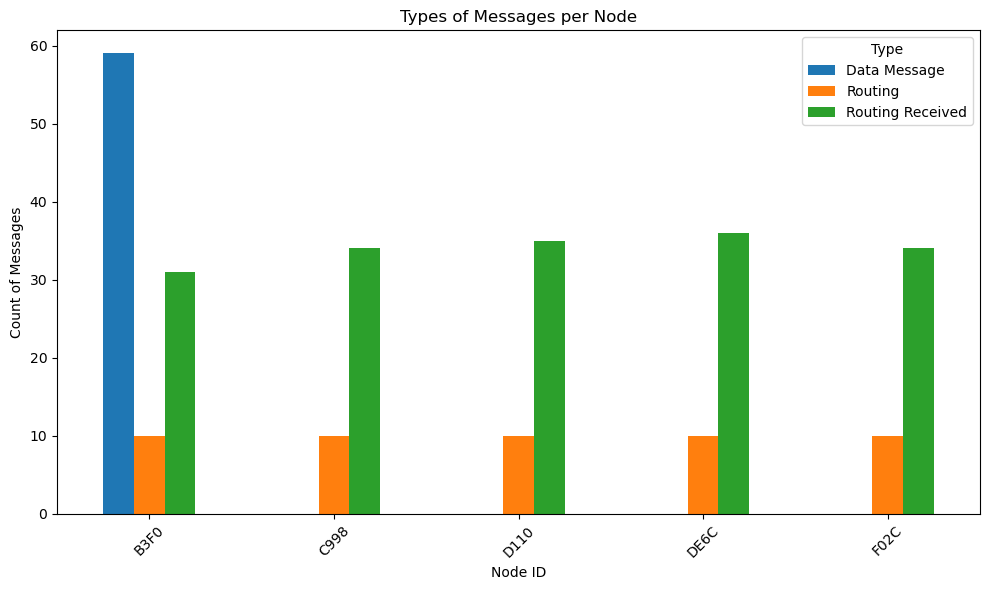

Packet Delivery Ratio (PDR):


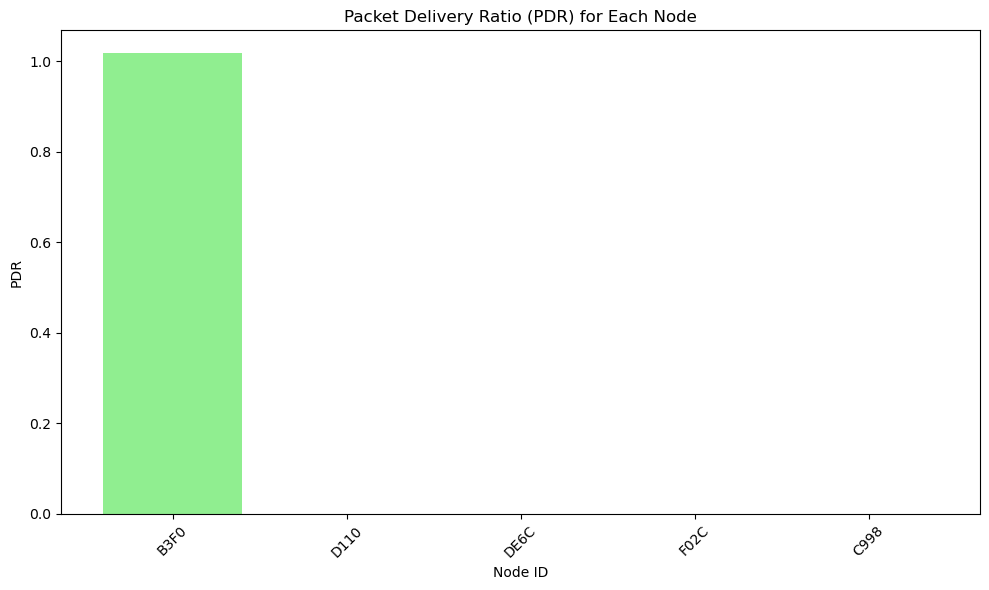

C:\Users\tripa\AppData\Local\Temp\ipykernel_10752\624477972.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([time_diff[id].dt.total_seconds() for id in time_diff.keys()], labels=time_diff.keys())


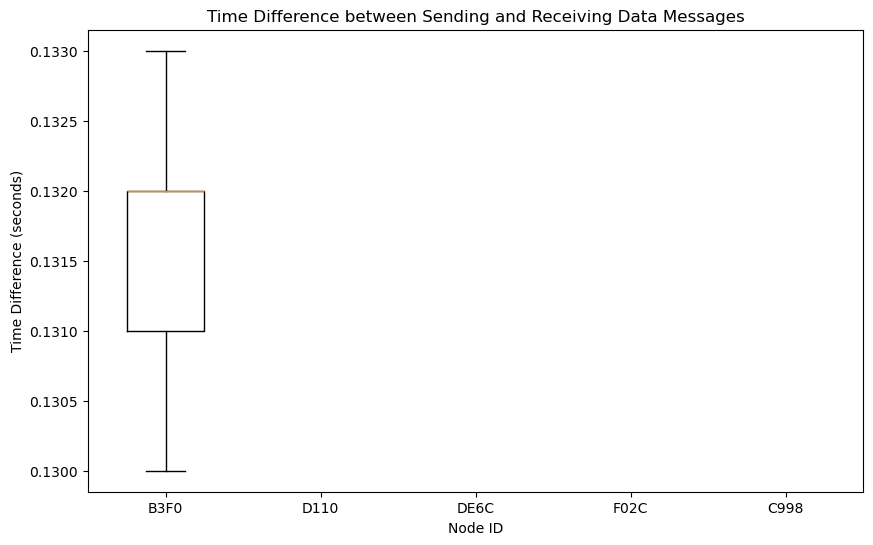

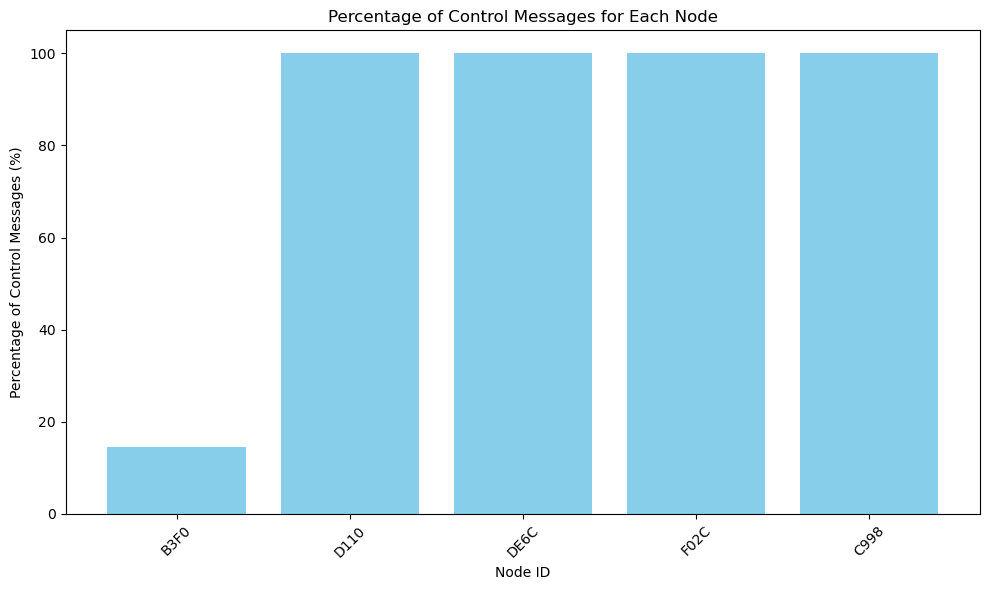

In [21]:
after_c998 = df.copy()
after_c998 = after_c998[after_c998['Timestamp'] >= c998['Timestamp'].min()]
after_c998 = pd.concat([after_c998, c998], ignore_index=True)
analyze(after_c998)